# Lab 1 · Your First Network: the PyTorch training loop
**MSACL · DS301 Deep Learning · Segment 1 · Lab 1**

Welcome to your first hands-on lab! This is a ~50-minute session, and the goal is simple:
get comfortable with **Colab** and **PyTorch**, and run one small neural network through the exact
**train → evaluate** loop you saw in Lecture 2.

> **You fill in a few short cells — everything else runs for you.**
> Look for the cells marked **YOUR TURN ✏️**: you'll write the training loop, run a quick
> learning-rate experiment, evaluate on held-out patients, and measure overfitting. Run every
> other cell exactly as it is.

We'll train a network to predict a person's biological **sex** from their **serum metabolite panel**
(189 measured metabolites) — the kind of tabular readout your instrument already produces.

## Running this notebook in Colab

> **First time with Colab?** Take the printed **“Setting up Google Colab”** sheet — it walks
> through opening this notebook, signing in, and saving your own copy, with screenshots.

**Before you type anything: `File → Save a copy in Drive`.** The link opens a read-only copy,
so without this your edits vanish when you close the tab. Work in the tab titled
*Copy of lab01_training_loop.ipynb*.

- A **notebook** is a list of *cells*. A cell holds either text (like this) or code.
- To run a code cell, click it and press **Shift + Enter** (or the ▶ button). Run the cells **in order, top to bottom**.
- **Run the ⚙️ Setup cell below first.** It installs the course packages and downloads the data for you (about a minute), ending with `✓ lab01 is ready`. You never download data files yourself.
- If anything gets tangled, use **Runtime → Restart session and run all** to start fresh.

No GPU is needed for this lab; the default CPU runtime is plenty.


## ⚙️ Setup — run this cell first

Run the next cell **before anything else**. On Colab it installs the course's
packages and downloads the data for this lab, checking every file's fingerprint;
on your own computer it uses the files already in the course folder. It takes
about a minute the first time. You do not need to read or edit it.

In [1]:
# ── MSACL DS301 · SETUP — run this cell first; no need to read or edit it ──
import sys, subprocess, urllib.request, pathlib
if "google.colab" in sys.modules:          # on Colab: fetch the course helper
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "uv"], check=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/indigobio/msacl_dl_course/main/student_pack/msacl.py",
        "msacl.py")
else:                                        # locally: use the course folder's copy
    here = pathlib.Path.cwd()
    helper = next(p for d in (here, *here.parents)
                  for p in (d / "msacl.py", d / "student_pack" / "msacl.py") if p.exists())
    sys.path.insert(0, str(helper.parent))
import msacl
DATA = msacl.setup("lab01")                  # {file name: where it is on this machine}

MSACL DS301 · setting up lab01
  ✓ MTBLS90.xlsx  (repo copy)
✓ lab01 is ready — 1 dataset(s), cached on your machine.


In [2]:
# Read and run — no need to edit.
# --- import the tools we'll use ---
import numpy as np                # numpy: fast math on big arrays of numbers
import pandas as pd               # pandas: reads spreadsheets/tables (our .xlsx data)
import torch                      # PyTorch: builds and trains the neural network
import torch.nn as nn            # nn: ready-made network pieces (layers, losses)
import matplotlib.pyplot as plt  # matplotlib: draws the loss curve

# Fix the random seeds so everyone gets the same numbers on every run.
np.random.seed(0)                 # seed numpy (used when we shuffle for the split)
torch.manual_seed(0)              # seed PyTorch (used when weights are first set)
print("PyTorch version:", torch.__version__)  # confirm PyTorch loaded

PyTorch version: 2.13.0


## About the data: MTBLS90

Before we train anything, let's understand what we're feeding the network.

**MTBLS90** is a public **serum LC–MS metabolomics** dataset — essentially the kind of readout
your own instrument produces: for each blood-serum sample, a mass spectrometer measures the
abundance of many small molecules (*metabolites*). We use it because it is real clinical-lab data,
it is freely downloadable with no sign-up, and it is big enough to train on yet small enough to
run in this lab.

- **Source:** MetaboLights study **MTBLS90**; the Excel file is mirrored by the CIMCB teaching
  repository (Mendez, Broadhurst, Reinke *et al.*). Public, open data.
- **Size:** **968 samples** (patients) × **189 metabolite features**.
- **Label:** biological **sex** — a balanced binary target (**485 male / 483 female**).
- **Missing values:** **none** (0 NaNs) — no cleanup needed.

### How the table is laid out
When we load the `Data` sheet we get a table (a pandas *DataFrame*) with these columns:

| Column group | What it is | Use in this lab |
|---|---|---|
| `Idx`, `SampleID` | row number and sample name (bookkeeping) | ignored |
| `Class` | 1 = male, 0 = female | **the label** (what we predict) |
| `Sex` | the same info as text (`"M"` / `"F"`) | ignored (we use `Class`) |
| `M1`, `M2`, …, `M189` | the 189 metabolite measurements | **the features** (network input) |

So: **features = the 189 `M#` columns**, **label = `Class`**. The `M#` labels are codes; the
human-readable metabolite names live in a separate `Peak` sheet in the same file (we don't need
them to train — that's just where you'd look them up).

## Step 1 · Load the data *(runs for you)*
We download the Excel file straight from the web and read its `Data` sheet into a table.

In [3]:
# Read and run — no need to edit.
# The setup cell at the top already fetched this dataset and checked its fingerprint;
# DATA maps each file name to where it now lives on this machine.
df = pd.read_excel(DATA["MTBLS90.xlsx"], sheet_name="Data")   # read the 'Data' sheet into a DataFrame
print("Table shape:", df.shape)              # (rows, columns) = (968 samples, 193 columns)
df.head(3)                                    # peek at the first 3 rows

Table shape: (968, 193)


/Users/lixingsong/Teaching/MSACL_DL_Course/student_pack/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Idx,SampleID,Class,Sex,M1,M2,M3,M4,M5,M6,...,M180,M181,M182,M183,M184,M185,M186,M187,M188,M189
0,1,subject_1524,0,Female,14.98474,14.49947,12.097435,12.043818,11.436392,16.07217,...,20.70097,20.19814,21.28179,21.09176,16.46404,12.269896,17.29323,19.81546,19.35259,12.71608
1,2,subject_1525,1,Male,15.17667,14.50172,12.363773,12.240458,11.577436,14.93265,...,21.68605,20.51608,21.25777,20.53935,16.33413,12.031267,18.08144,19.96693,19.50694,13.20891
2,3,subject_1527,1,Male,15.35934,14.41941,12.510494,11.234959,11.199970,15.22600,...,20.46320,20.34297,21.34793,20.81883,16.44281,12.679043,17.24765,20.01505,20.34058,12.98210


In [4]:
# Read and run — no need to edit.
# Build the list of the 189 feature column names: "M1", "M2", ..., "M189".
feature_cols = [f"M{i}" for i in range(1, 190)]   # range(1, 190) gives the numbers 1..189

# X = the inputs: pull out just the metabolite columns and turn them into a numeric array.
X = df[feature_cols].to_numpy("float32")          # shape (968, 189)

# y = the label: 1 = male, 0 = female.
y = df["Class"].to_numpy("float32")               # shape (968,)

print("X (inputs):", X.shape)                     # (968, 189)
print("y (labels):", y.shape,
      "| counts [female, male]:", np.bincount(y.astype(int)))  # ~[483, 485], nearly balanced

X (inputs): (968, 189)
y (labels): (968,) | counts [female, male]: [483 485]


Here's what a single **sample** looks like — 189 metabolite measurements for one person. A
"sample" is just a row of numbers, and the network sees exactly this.

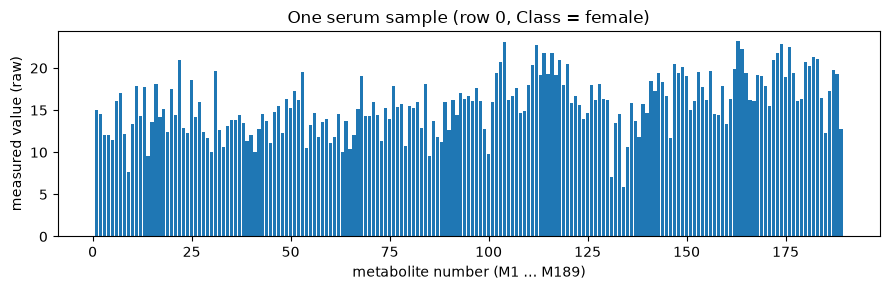

In [5]:
# Read and run — no need to edit.
# Let's look at ONE patient so you can see that a "sample" is just a row of 189 numbers.
sample_row = 0                                    # pick the first patient (row 0); try other rows if you like
sample_values = X[sample_row]                     # that patient's 189 RAW metabolite values (before normalizing)
sample_label = "male" if y[sample_row] == 1 else "female"  # translate the 0/1 Class into a word

plt.figure(figsize=(9, 3))                        # a wide, short figure fits 189 bars nicely
plt.bar(range(1, 190), sample_values)             # x = metabolite number 1..189, y = its measured value
plt.xlabel("metabolite number (M1 … M189)")       # x-axis: which metabolite
plt.ylabel("measured value (raw)")                # y-axis: its abundance, before normalization
plt.title(f"One serum sample (row {sample_row}, Class = {sample_label})")  # label with this patient's sex
plt.tight_layout()                                # keep the labels from being clipped
plt.show()                                         # display the figure

## Step 2 · Split and normalize — by hand *(runs for you)*
Two standard preparation steps. We do them **by hand with numpy** (no libraries) so you can see
exactly what happens:

1. **Split** the 968 samples into a **training set** (~80%, to learn from) and a **test set**
   (~20%, to check honestly on samples the model never saw). We shuffle the row order first, using
   a fixed seed so the split is identical on every run.
2. **Normalize (z-score)** each metabolite to roughly mean 0, spread 1: subtract the column's mean
   and divide by its standard deviation. Networks train far better when all inputs share a scale.

> **Why compute the mean/std on the training set only?** The test set stands in for *future,
> unseen patients*. If we used it to compute the scaling, we'd be leaking test information into
> training and our accuracy would be dishonestly high. So we learn mean/std from **train only**,
> then apply those same numbers to both train and test.

In [6]:
# Read and run — no need to edit.
# --- 1. Shuffle the row order, then slice an 80/20 split ---
n_samples = X.shape[0]                    # 968 rows in total
indices = np.arange(n_samples)            # [0, 1, 2, ..., 967]
np.random.shuffle(indices)                # shuffle in place (seed fixed above -> same order every run)

n_train = int(0.8 * n_samples)            # keep 80% for training -> 774 rows
train_idx = indices[:n_train]             # first 774 shuffled rows -> training
test_idx  = indices[n_train:]             # the remaining 194 rows  -> testing

X_train, y_train = X[train_idx], y[train_idx]   # grab the training rows
X_test,  y_test  = X[test_idx],  y[test_idx]    # grab the test rows

# --- 2. Z-score normalize using TRAIN statistics only ---
mean = X_train.mean(axis=0)               # per-metabolite mean, computed on TRAIN only
std  = X_train.std(axis=0) + 1e-8         # per-metabolite std (+ tiny number avoids divide-by-zero)

X_train = (X_train - mean) / std          # apply the train mean/std to the training data
X_test  = (X_test  - mean) / std          # apply the SAME train mean/std to the test data (never refit!)

# --- 3. Convert numpy arrays into PyTorch tensors (what the network computes on) ---
X_train = torch.tensor(X_train, dtype=torch.float32)   # (774, 189)
X_test  = torch.tensor(X_test,  dtype=torch.float32)   # (194, 189)
# Labels become float COLUMN vectors of shape (N, 1) to match the network's (N, 1) output.
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)   # (774, 1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1)   # (194, 1)

print("training samples:", X_train.shape[0], "| test samples:", X_test.shape[0])
print("y_train shape:", tuple(y_train.shape), "(a column vector, to match the model output)")

training samples: 774 | test samples: 194
y_train shape: (774, 1) (a column vector, to match the model output)


## Step 3 · Build the network — by hand *(runs for you)*
We define the network as a small **class**. Think of the class as a blueprint with two parts:

- `__init__` **lists the layers** (created once): `fc1` maps 189 inputs → 16 hidden neurons;
  `fc2` maps those 16 → 1 output.
- `forward` **describes the path** an input takes, step by step: `fc1` → **ReLU** (the "bend" from
  Lecture 1) → `fc2` → **sigmoid** (squash to a 0–1 probability).

It's the same tiny network as the slides (189 → 16 → 1), just written out explicitly so you can see
every layer. (`fc` stands for *fully connected*, another name for `nn.Linear`.)

We also need two more pieces: the **loss** — MSE, how wrong the guess is (Lecture 2; *Lecture 4
introduces the proper classification loss, cross-entropy*) — and the **optimizer** — Adam, the rule
that nudges the weights downhill.

In [7]:
# Read and run — no need to edit.
class MetaboliteNet(nn.Module):          # our network, built on PyTorch's base class nn.Module
    def __init__(self):
        super().__init__()               # required: switch on the nn.Module machinery
        self.fc1 = nn.Linear(189, 16)    # layer 1: 189 metabolite inputs -> 16 hidden neurons
        self.relu = nn.ReLU()            # activation: the "bend" that lets the net learn curves
        self.fc2 = nn.Linear(16, 1)      # layer 2: 16 hidden neurons -> 1 output number
        self.sigmoid = nn.Sigmoid()      # squash that output into a probability between 0 and 1

    def forward(self, x):                # forward: how an input x flows through the network
        x = self.fc1(x)                  # 1. multiply by layer 1's weights (189 -> 16)
        x = self.relu(x)                 # 2. apply ReLU to the 16 hidden values
        x = self.fc2(x)                  # 3. multiply by layer 2's weights (16 -> 1)
        x = self.sigmoid(x)              # 4. squash to a 0..1 probability
        return x                         # hand back the prediction

model = MetaboliteNet()                  # create one network from the blueprint
print(model)                             # print its layers

MetaboliteNet(
  (fc1): Linear(in_features=189, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [8]:
# Read and run — no need to edit.
loss_fn   = nn.MSELoss()                                    # loss: how wrong the guess is (Lecture 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # optimizer: the rule that nudges weights downhill

## Step 4 · Train the network — YOUR TURN ✏️
This is the first cell you write. Fill in the **five lines of the training loop** from Lecture 2,
**in order**:

1. **forward** — make a guess with the model
2. **loss** — measure how wrong the guess is
3. **zero** — clear last step's gradients
4. **backward** — backprop the blame
5. **step** — nudge every weight

**Your Turn — the names you'll use** (these are the pieces, not the answers):
`model`, `X_train`, `y_train`, `loss_fn`, `optimizer`, and the methods
`.zero_grad()`, `.backward()`, `.step()`. Store the guess in `pred` and the loss in `loss`.

Stuck? The paper **hint sheet** lists multiple-choice options for each line. Run the cell when
you're done — the `assert` checks underneath will tell you if it worked.

In [9]:
EPOCHS = 150
loss_history = []

for epoch in range(EPOCHS):
    ### BEGIN SOLUTION
    pred = model(X_train)              # 1. forward  — make a guess
    loss = loss_fn(pred, y_train)      # 2. loss     — how wrong?
    optimizer.zero_grad()              # 3. zero     — clear old gradients
    loss.backward()                    # 4. backward — backprop the blame
    optimizer.step()                   # 5. step     — nudge every weight
    ### END SOLUTION
    loss_history.append(loss.item())   # (written for you) record the loss

# --- self-checks: do not edit ---
assert len(loss_history) == EPOCHS, "The loop should record one loss per epoch."
assert model.fc1.weight.grad is not None, "No gradients — did you call loss.backward()?"
assert loss_history[-1] < 0.5 * loss_history[0], \
    "The loss barely fell — did you call optimizer.step() to update the weights?"
print(f"first-epoch loss {loss_history[0]:.3f}  ->  last-epoch loss {loss_history[-1]:.3f}")
print("Nice — the loss fell. Your network is learning!")

first-epoch loss 0.261  ->  last-epoch loss 0.010
Nice — the loss fell. Your network is learning!


## Step 5 · Watch it learn *(runs for you)*
Plot the loss at every epoch. You should see the **Lecture 2 loss curve**: a steep drop that
flattens out — proof the network is improving with each step.

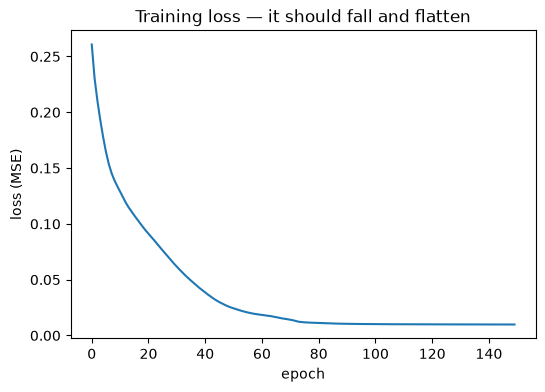

In [10]:
# Read and run — no need to edit.
plt.figure(figsize=(6, 4))                      # start a new figure
plt.plot(loss_history)                           # y = loss at each epoch (x = epoch number)
plt.xlabel("epoch"); plt.ylabel("loss (MSE)")    # label the axes
plt.title("Training loss — it should fall and flatten")
plt.show()                                        # display the figure

## Step 6 · The learning rate: watch the curve change — YOUR TURN ✏️
In Lecture 2 you saw that the **learning rate** is the size of each downhill step. It has three
regimes, and you are going to find all three on the real metabolite data:

- **too small** — each step is tiny, so after 150 epochs the loss has barely moved (it *crawls*);
- **about right** — the loss falls fast and settles low;
- **too big** — every step overshoots the valley, so the loss **climbs** instead of falling.

The helper `train_quick(lr)` below trains a **brand-new** network at the learning rate you give it,
for the same `EPOCHS`, and returns its loss at every epoch. `plot_runs(...)` draws several of those
curves on one plot, with each run's **start → end** loss in the legend. Neither touches the `model`
you trained in Step 4.

In [11]:
# Read and run — no need to edit. (The two helpers you'll use next.)
def train_quick(lr):
    """Train a FRESH network at the given learning rate and return its loss history.
    Does not touch the `model`/`loss_history` you trained in Step 4."""
    torch.manual_seed(1)                       # fixed local seed -> reproducible for everyone
    fresh_model = MetaboliteNet()              # a brand-new network (fresh random weights)
    fresh_opt   = torch.optim.Adam(fresh_model.parameters(), lr=lr)  # its own optimizer at this lr
    history = []                               # collect the loss at each epoch
    for epoch in range(EPOCHS):                # same number of epochs as Step 4
        pred = fresh_model(X_train)            # forward
        loss = loss_fn(pred, y_train)          # loss
        fresh_opt.zero_grad()                  # zero
        loss.backward()                        # backward
        fresh_opt.step()                       # step
        history.append(loss.item())            # record it
    return history                             # hand back the whole curve

def plot_runs(runs, title):
    """Draw every {learning rate: loss history} in `runs` on one plot."""
    plt.figure(figsize=(9, 4))
    for lr, hist in runs.items():
        plt.plot(hist, label=f"lr = {lr:g}:  loss {hist[0]:.3f} → {hist[-1]:.3f}")
    plt.xlabel("epoch"); plt.ylabel("loss (MSE)")
    plt.title(title)
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))   # outside, so it never hides a curve
    plt.tight_layout()
    plt.show()

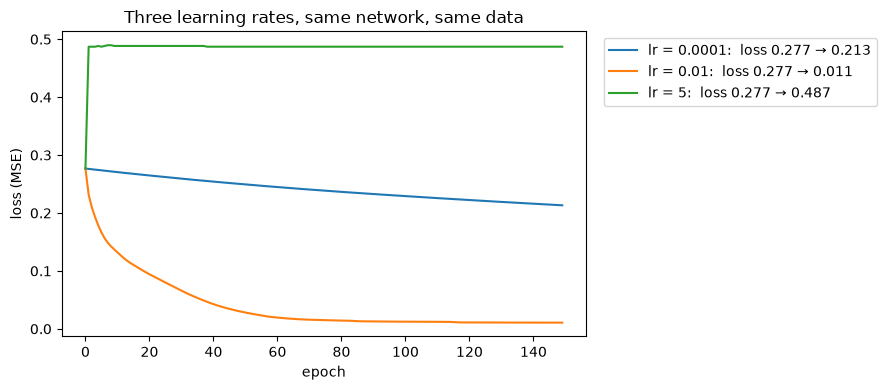

All three regimes found — you read them straight off the curves.


In [12]:
# YOUR TURN: pick one learning rate that is TOO SMALL and one that is TOO BIG.
lr_ok = 0.01                          # a sensible rate (this one is given)

# Blank 1: set lr_too_small — a rate so small the loss barely moves in 150 epochs
### BEGIN SOLUTION
lr_too_small = 0.0001                  # 100x smaller -> tiny steps, the loss crawls
### END SOLUTION

# Blank 2: set lr_too_big — a rate so big the loss climbs instead of falling
### BEGIN SOLUTION
lr_too_big = 5.0                       # 500x bigger -> every step overshoots
### END SOLUTION

hist_small = train_quick(lr_too_small)
hist_ok    = train_quick(lr_ok)
hist_big   = train_quick(lr_too_big)
plot_runs({lr_too_small: hist_small, lr_ok: hist_ok, lr_too_big: hist_big},
          "Three learning rates, same network, same data")

# --- self-checks: do not edit ---
assert lr_too_small < lr_ok < lr_too_big, \
    "Order them: lr_too_small must be below lr_ok (0.01), and lr_too_big above it."
assert hist_small[-1] < hist_small[0] and hist_small[-1] > 3 * hist_ok[-1], \
    "Too small should still be CRAWLING after 150 epochs: its loss falls, but ends far above lr_ok's. Try a smaller value."
assert hist_big[-1] > hist_big[0], \
    "Too big should make the loss RISE (last loss above the first). Try a bigger value."
print("All three regimes found — you read them straight off the curves.")

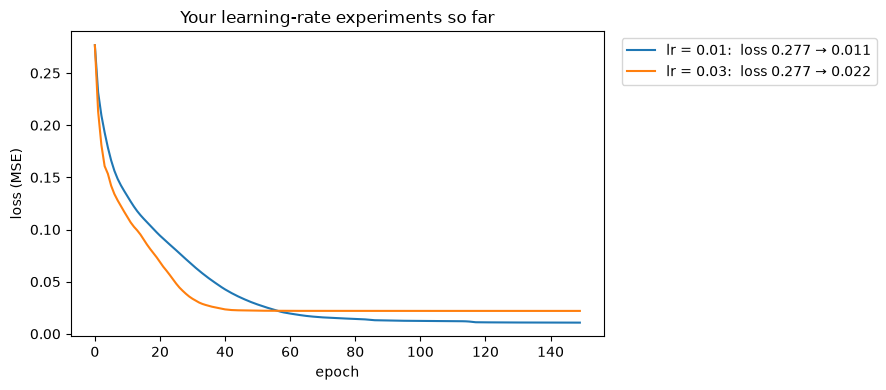

lr = 0.01     final loss 0.011   (worst along the way 0.277)
lr = 0.03     final loss 0.022   (worst along the way 0.277)


In [13]:
# Explore — no blank to grade. Change `lr_try`, re-run this cell (Shift + Enter), and watch.
# Every run is ADDED to the plot, so the curves pile up and you can compare them.
# Try, one at a time:  0.001   0.003   0.03   0.1   0.3   1.0
lr_try = 0.03

explore_runs = globals().get("explore_runs", {lr_ok: hist_ok})   # remembers earlier runs
explore_runs[lr_try] = train_quick(lr_try)
plot_runs(dict(sorted(explore_runs.items())), "Your learning-rate experiments so far")

# the table under the plot: final loss for every rate you've tried, lowest first
for lr, hist in sorted(explore_runs.items(), key=lambda kv: kv[1][-1]):
    print(f"lr = {lr:<8g} final loss {hist[-1]:.3f}   (worst along the way {max(hist):.3f})")

**What to notice** (💬 compare with your neighbour):
- `0.03` drops **faster** than `0.01` in the first few epochs — yet ends **higher**. Bigger steps
  get you near the bottom sooner, then keep hopping around it.
- At `0.1` the curve **wobbles**: its worst loss along the way is higher than where it started, even
  though it ends lower. At `0.3` and above, it no longer settles at all.
- There is no universal best rate. You find it exactly like this: try a few, spaced ×3 or ×10
  apart, and read the curves.

## Step 7 · Evaluate on the test set — YOUR TURN ✏️
Training accuracy can lie — the model has *seen* that data. The honest test is on the **held-out
test samples**. Fill in the evaluation:

- wrap the prediction in `with torch.no_grad():` (we're only checking, not learning — no gradients needed),
- turn the 0–1 probabilities into 0/1 predictions with a **0.5 threshold**,
- compute the fraction that match the true label.

**Your Turn — the names you'll use** (not the answers): `torch.no_grad()`, `model(X_test)`, the
threshold `0.5`, `y_test`, and `.float().mean()` to get the fraction correct. Store the result in
`test_acc`.

In [14]:
### BEGIN SOLUTION
with torch.no_grad():                       # no learning here — just checking
    probs = model(X_test)                   # predicted probabilities, 0..1
predicted = (probs > 0.5).float()           # 0.5 threshold -> 0/1 prediction
test_acc = (predicted == y_test).float().mean().item()   # fraction that match the label
### END SOLUTION

# --- self-checks: do not edit ---
assert 0.0 <= test_acc <= 1.0, "Accuracy must be a fraction between 0 and 1."
assert test_acc > 0.65, "Expected clearly above the 0.50 coin-flip baseline."
print(f"Test accuracy: {test_acc:.3f}    (coin-flip baseline: 0.50)")

Test accuracy: 0.742    (coin-flip baseline: 0.50)


## Step 8 · Did it overfit? Compute the gap yourself — YOUR TURN ✏️
The test accuracy above is the honest score. But how *hard* did the network memorize the training
data? Measure it: compute the **training accuracy** the same way you just computed the test
accuracy, then compare the two. If training accuracy is clearly higher than test accuracy, the
model did better on data it had already seen than on new patients — that gap is **overfitting**,
the problem Lecture 4 is all about.

**Your Turn — the names you'll use** (not the answers): `torch.no_grad()`, `model(X_train)`, the
`0.5` threshold, `y_train`, and `.float().mean().item()`. Store the result in `train_acc`, then
fill the comparison so `overfitting` is `True` when training beats test.

In [15]:
### BEGIN SOLUTION
with torch.no_grad():                          # no learning — just checking, like Step 7
    probs_train = model(X_train)               # predicted probabilities on the TRAINING data
predicted_train = (probs_train > 0.5).float()  # 0.5 threshold -> 0/1 prediction
train_acc = (predicted_train == y_train).float().mean().item()  # fraction correct on train
### END SOLUTION

# DECIDE: overfitting means the model scores HIGHER on data it has seen. Fill the comparison (> or <):
### BEGIN SOLUTION
overfitting = train_acc > test_acc
### END SOLUTION

gap = train_acc - test_acc                      # how much better on seen data than unseen

# --- self-checks: do not edit ---
assert 0.0 <= train_acc <= 1.0, "Accuracy must be a fraction between 0 and 1."
assert train_acc >= test_acc, "Training accuracy should be at least as high as test accuracy here."
assert overfitting is True, "With train_acc above test_acc, the model IS overfitting — fix the comparison."
print(f"train accuracy: {train_acc:.3f}   test accuracy: {test_acc:.3f}   gap: {gap:+.3f}")
print("The model scores higher on data it has seen — that gap is overfitting (the Lecture 4 problem).")

train accuracy: 0.991   test accuracy: 0.742   gap: +0.249
The model scores higher on data it has seen — that gap is overfitting (the Lecture 4 problem).


## What just happened
You built and trained a real neural network — by hand, end to end — and then probed it:

- the **loss fell** as the network learned (Steps 4–5),
- you saw a **too-big learning rate overshoot** and drive the loss *up* instead of down (Step 6) —
  the Lecture 2 diagnosis, straight off the curve,
- it reached roughly **0.72–0.77 accuracy** on samples it had never seen (Step 7) — well above the
  **0.50** coin-flip baseline, so it found real signal in the metabolite panel,
- and you measured a large **train − test gap** (Step 8): the model scores far higher on data it
  has already seen.

That gap is **overfitting**: predicting sex from metabolites is genuinely hard, and the model
memorizes the training patients more than it generalizes. Closing that gap — and picking a good
learning rate — is exactly what **Lecture 4** is about.

## Optional stretch *(only if you're ahead)*
Curious what moves the result? Change **one** small thing and then **Runtime → Run all**:

- change `EPOCHS` in Step 4 (try `50` or `300`), **or**
- change the hidden width `16` in Step 3's model — edit **both** `nn.Linear(189, 16)` and
  `nn.Linear(16, 1)` to the same new number (try `4` or `64`).

Watch the loss curve and the test accuracy move. There's no single right answer — this is the
tuning you'll do for real in later labs.